In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.fillna({'Age': df['Age'].median()}, inplace=True)
df.dropna(subset=['Embarked'], inplace=True)
df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
df['AgeGroup'] = df['Age'].apply(lambda x: 'Child' if x<13 else 'Teen' if x<18 else 'Adult' if x<61 else 'Senior')
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
 12  Title        888 non-null    object 
 13  AgeGroup     889 non-null    object 
 14  Sex_encoded  889 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 111.1+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_encoded
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681,0.350956
std,256.998173,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504,0.477538
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [ ]:
# recall day 3

# 1. GroupBy survival rate by Pclass
# 2. Pivot table — Pclass vs Sex vs Survived
# 3. Merge df1 and df2 on PassengerId, left join

In [ ]:
#GroupBy survival by Pclass

#1.
df.groupby("Pclass")['Survived'].mean()

,Survived
Pclass,
1,0.626168
2,0.472826
3,0.242363


In [ ]:
#Pivot table Pclass vs Sex
pd.pivot_table(df,values="Survived", index="Pclass",columns="Sex",aggfunc="mean")

Sex,female,male
Pclass,,
1,0.967391,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [ ]:
#Left merge on PassengerId
df1 = pd.DataFrame({'PassengerId': [1, 2, 3, 4], 'Name': ['Alice', 'Bob', 'Charlie', 'Dave']})
df2 = pd.DataFrame({'PassengerId': [2, 2, 4, 5], 'Score': [85, 90, 78, 92]})

df1.merge(df2,on="PassengerId", how="left")

,PassengerId,Name,Score
0,1,Alice,NaN
1,2,Bob,85.0
2,2,Bob,90.0
3,3,Charlie,NaN
4,4,Dave,78.0


# Day -4
-	Matplotlib: figure, axes, subplots — build a reusable plot function
-	Line, bar, scatter, histogram — one of each on the Titanic data
-	Customise: titles, labels, colours, figure size, tight_layout

In [ ]:
# Figure -> the whole canvas wherre one can paint and plot
# axes -> object of plots, instance of axes to plot things
#subplots- consists of different plots - bar,hist, scatter, line


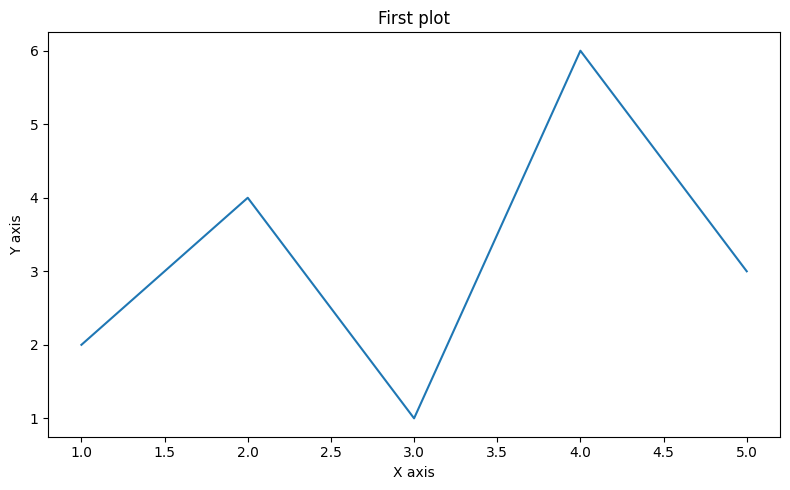

In [ ]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(8,5))
ax.plot([1,2,3,4,5], [2,4,1,6,3])
ax.set_title("First plot")
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
plt.tight_layout()
plt.show()

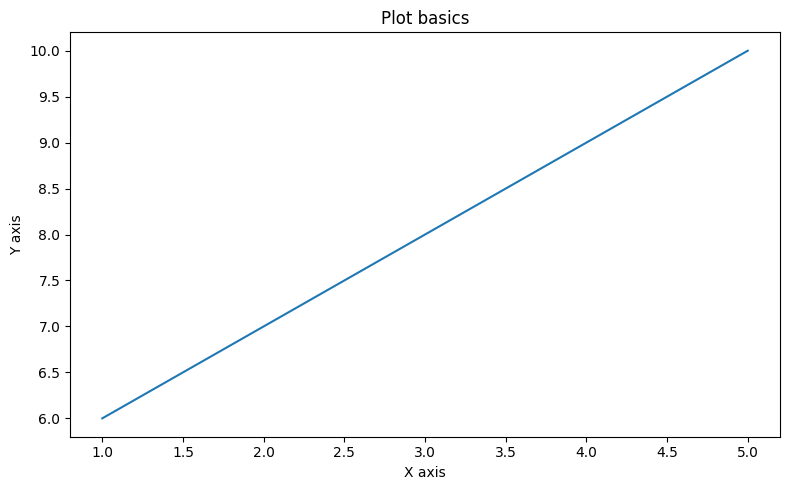

In [ ]:
# create a figure with 1 axes
figure, axes = plt.subplots(figsize=(8,5))

#plot with given points
axes.plot((1,2,3,4,5),(6,7,8,9,10))

axes.set_title("Plot basics")
axes.set_xlabel("X axis")
axes.set_ylabel("Y axis")

#Tight layout doesn't allow labels to flow out of bound
plt.tight_layout()   #One figure, multiple subplots --> without tight_layout() they overlap and titles/labels get cut off.

#helps to display plot  -It clears the figure so the next plot starts fresh
plt.show()

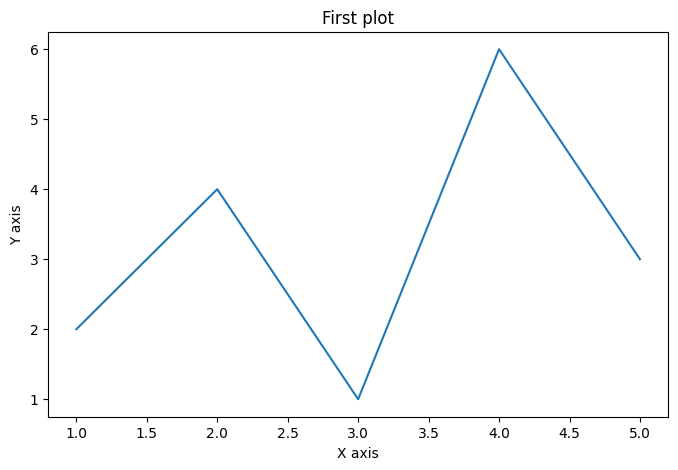

In [ ]:
fig,ax = plt.subplots(figsize=(8,5))
ax.plot([1,2,3,4,5], [2,4,1,6,3])
ax.set_title("First plot")
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
plt.show()

1. Bar chart = categories with gaps.
2. Histogram = continuous data, no gaps, shows distribution shape

In [ ]:
#Line, bar, scatter, histogram — one of each on the Titanic data

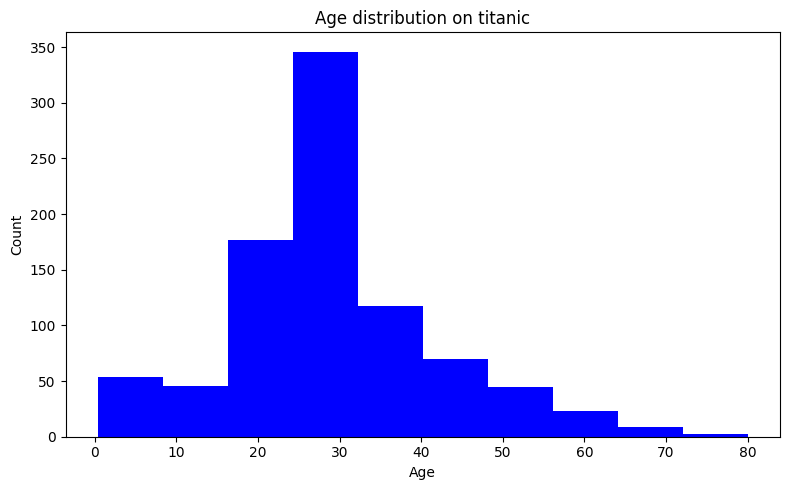

In [ ]:
#histogram
fig,ax = plt.subplots(figsize=(8,5))
ax.hist(x=df['Age'] , color="blue", bins=10)
ax.set_title("Age distribution on titanic")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

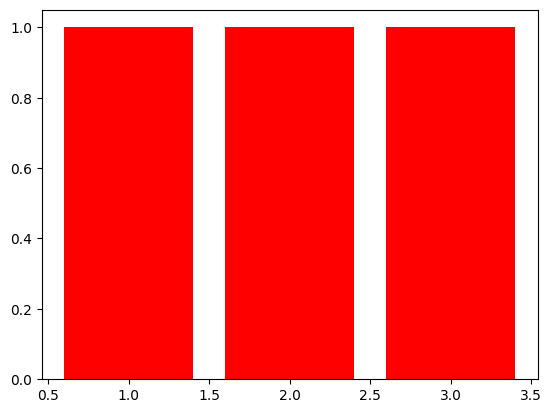

In [ ]:
 #bar chart — survival count by Pclass:
fig1,ax1 = plt.subplots()
ax1.bar(x=df['Pclass'],height=df['Survived'],color="red")
plt.show()

#passes all 889 values one bar per passenger-which is wrong

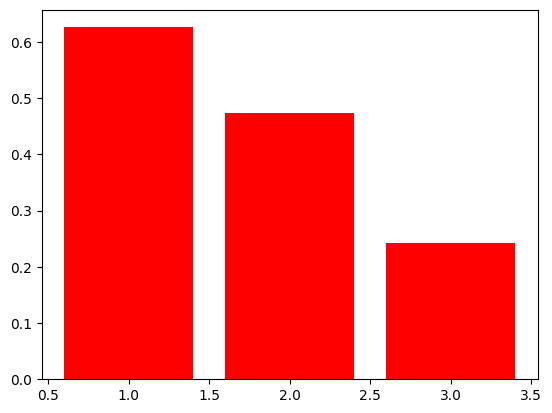

In [ ]:
fig1,ax1 = plt.subplots()
survival_by_class = df.groupby('Pclass')['Survived'].mean()
ax1.bar(x=survival_by_class.index,height=survival_by_class.values,color="red")
plt.show()

In [ ]:
print(survival_by_class.index)
print(survival_by_class.values)

Index([1, 2, 3], dtype='int64', name='Pclass')
[0.62616822 0.47282609 0.24236253]


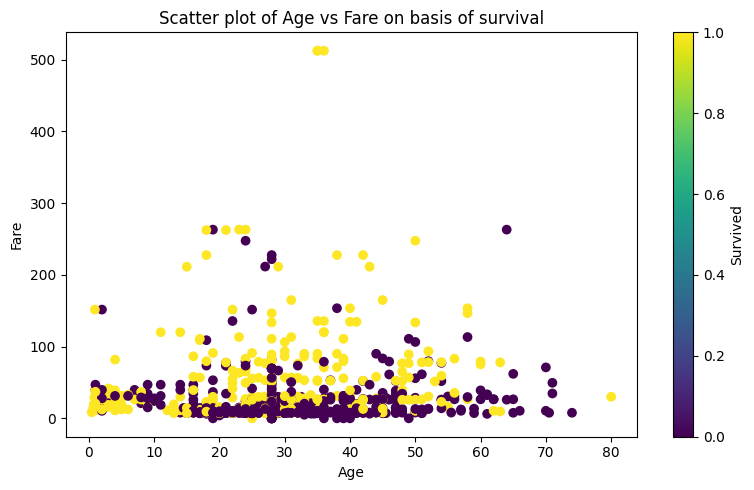

In [ ]:
#Scatter plot — Age vs Fare, coloured by survival:
#scatter(X-AXIS, Y-axis, c - colour variable)

fig , ax = plt.subplots(figsize=(8,5))
ax.scatter(x=df['Age'], y=df['Fare'], c=df['Survived'])
ax.set_title("Scatter plot of Age vs Fare on basis of survival")
ax.set_xlabel("Age")
ax.set_ylabel("Fare")

plt.colorbar(ax.collections[0], ax=ax, label='Survived')
plt.tight_layout()
plt.show()

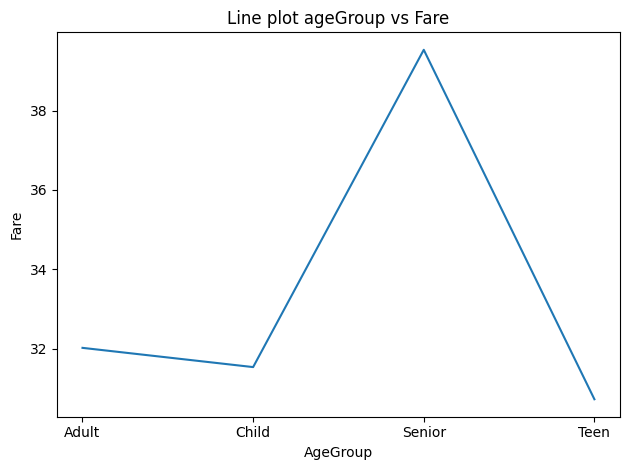

In [ ]:
#line
age = df.groupby('AgeGroup')['Fare'].mean()
age
fig, ax = plt.subplots()
ax.plot(age.index,age.values)
ax.set_title("Line plot ageGroup vs Fare")
ax.set_xlabel("AgeGroup")
ax.set_ylabel("Fare")
plt.tight_layout()
plt.show()

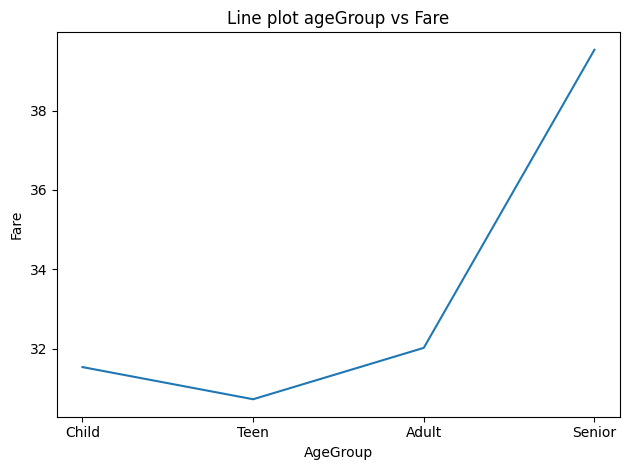

In [ ]:
#order AgeGroup and then plot
order = ['Child','Teen','Adult','Senior']
age_ordered = pd.Categorical(df['AgeGroup'], categories=order, ordered=True)

#age = df.groupby(age_ordered)['Fare'].mean()
age = df.groupby(age_ordered, observed=True)['Fare'].mean()         # --> observed=True → only show categories that have data
                                                                    #observed=False → show all categories even if no rows match
fig, ax = plt.subplots()
ax.plot(age.index,age.values)
ax.set_title("Line plot ageGroup vs Fare")
ax.set_xlabel("AgeGroup")
ax.set_ylabel("Fare")
plt.tight_layout()
plt.show()

In [ ]:
#Matplotlib: figure, axes, subplots — build a reusable plot function
def plot_chart(ax,plot_type,title,xlabel,ylabel,*args,**kwargs):
  #hist
  #naive approach
  #if plot_type == "hist":
  #  ax.hist(**kwargs)
  #  ax.set_title(title)
  #  ax.set_xlabel(xlabel)
  #  ax.set_ylabel(ylabel)
  #  plt.tight_layout()
  #  plt.show()

  getattr(ax,plot_type)(*args,**kwargs)
  ax.set_title(title)
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  plt.tight_layout()
  plt.show()

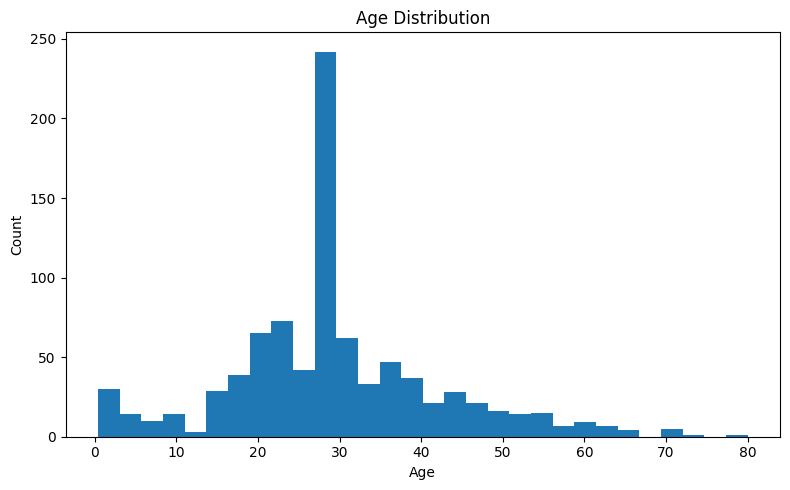

In [ ]:
fig,ax=plt.subplots(figsize=(8,5))
plot_chart(ax,'hist', 'Age Distribution', 'Age', 'Count', x=df['Age'], bins=30)

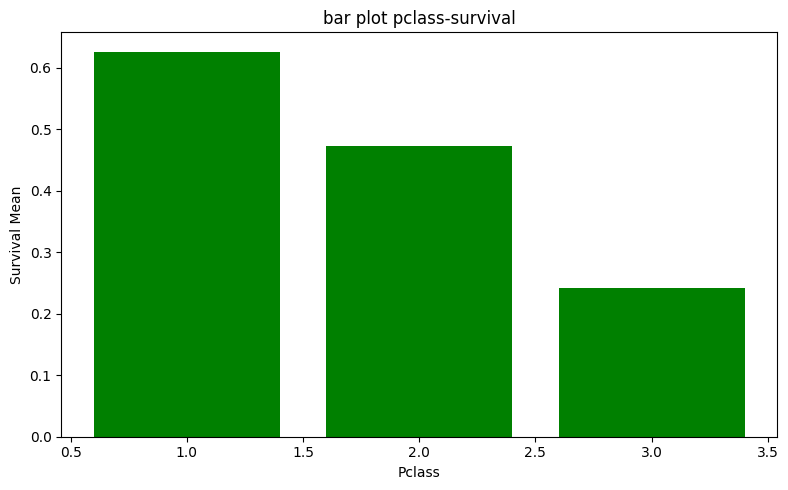

In [ ]:
survival_by_class = df.groupby('Pclass')['Survived'].mean()
fig,ax=plt.subplots(figsize=(8,5))
plot_chart(ax,'bar','bar plot pclass-survival','Pclass','Survival Mean',x=survival_by_class.index ,height=survival_by_class.values,color="green")

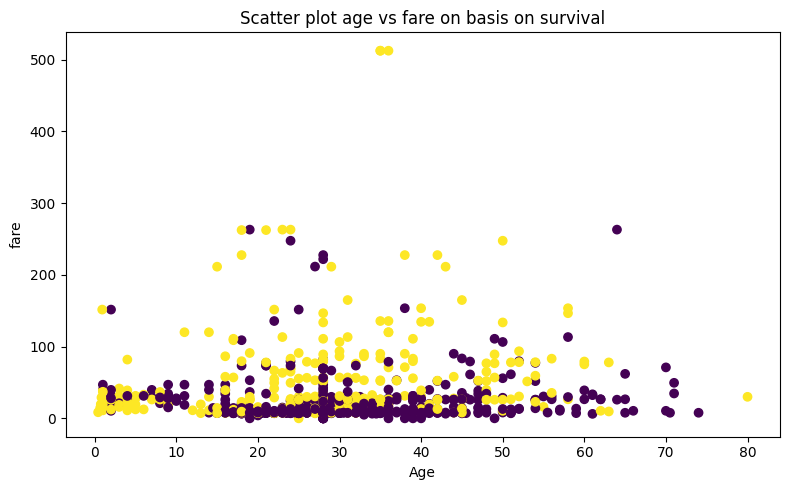

In [ ]:
fig,ax=plt.subplots(figsize=(8,5))
plot_chart(ax,'scatter','Scatter plot age vs fare on basis on survival','Age','fare',x=df['Age'],y=df['Fare'],c=df['Survived'])

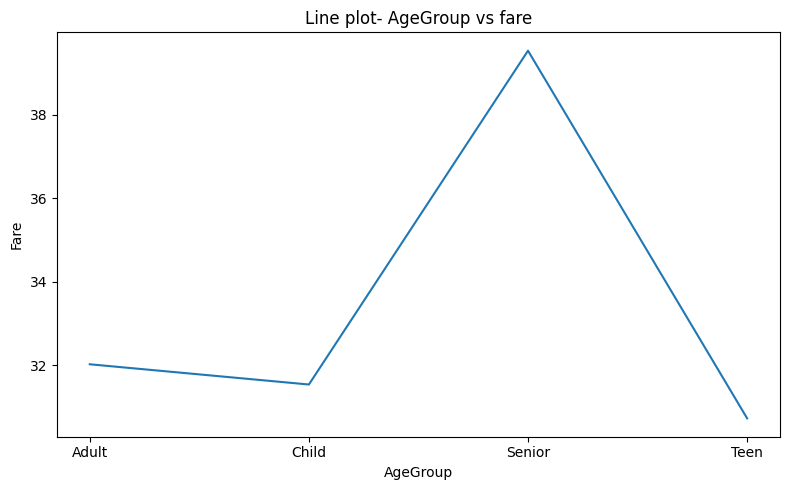

In [ ]:
age_mean_fare = df.groupby('AgeGroup')['Fare'].mean()

fig,ax=plt.subplots(figsize=(8,5))
plot_chart(ax,'plot','Line plot- AgeGroup vs fare','AgeGroup','Fare',age_mean_fare.index,age_mean_fare.values)

## Day 4 Done
-

> *_*_*_*_*_*_*_*_*_********_*_*_*_*_*_*_*_*_*_*_*_*_*_*_*__*_*_*_*_*



Text(0, 0.5, 'Y axis')

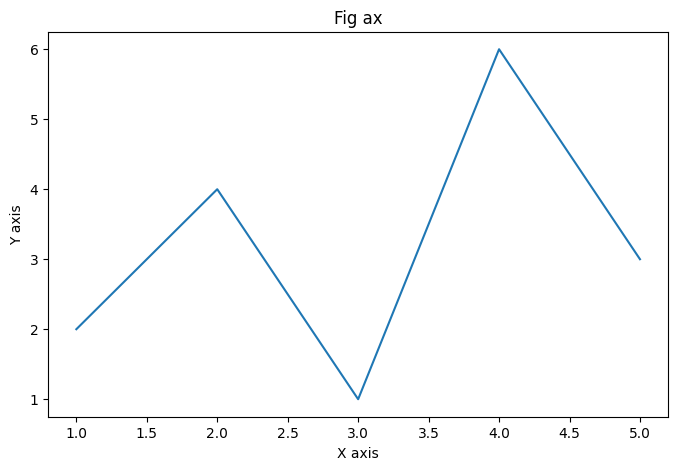

In [ ]:
fig2, ax2 = plt.subplots(figsize=(8,5))
ax2.plot([1,2,3,4,5], [2,4,1,6,3])
ax2.set_title("Fig ax")
ax2.set_xlabel("X axis")
ax2.set_ylabel("Y axis")

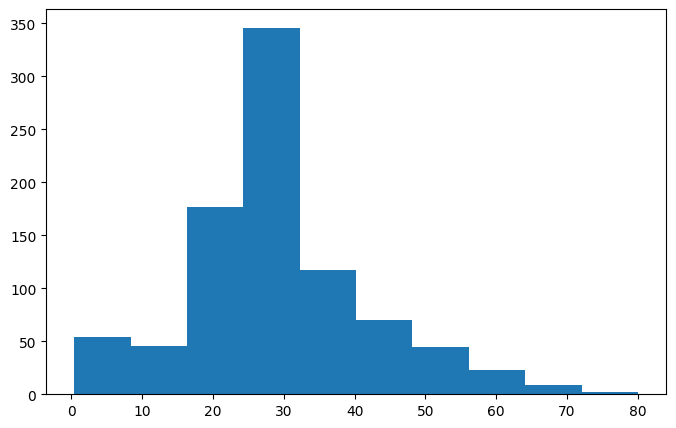

In [ ]:
fig2, ax2 = plt.subplots(figsize=(8,5))
ax2.hist(x=df['Age'])
plt.show()

In [ ]:
#•	Matplotlib: figure, axes, subplots — build a reusable plot function
#•	Line, bar, scatter, histogram — one of each on the Titanic data
#•	Customise: titles, labels, colours, figure size, tight_layout


In [ ]:
# 1. histogram of Age
# 2. bar chart of survival by Pclass
# 3. set title, xlabel, ylabel on both

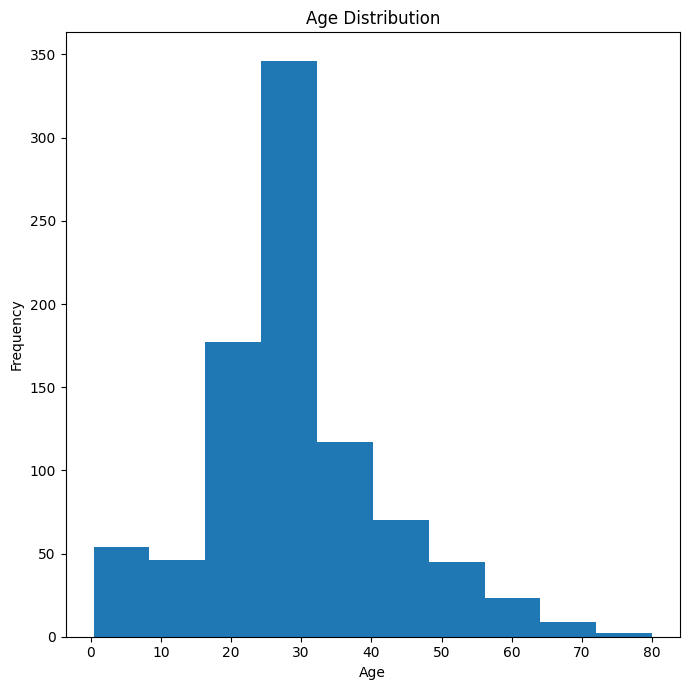

In [ ]:
fige, axr = plt.subplots(figsize=(7,7))
axr.hist(x=df['Age'],bins=10)
axr.set_title("Age Distribution")
axr.set_xlabel("Age")
axr.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

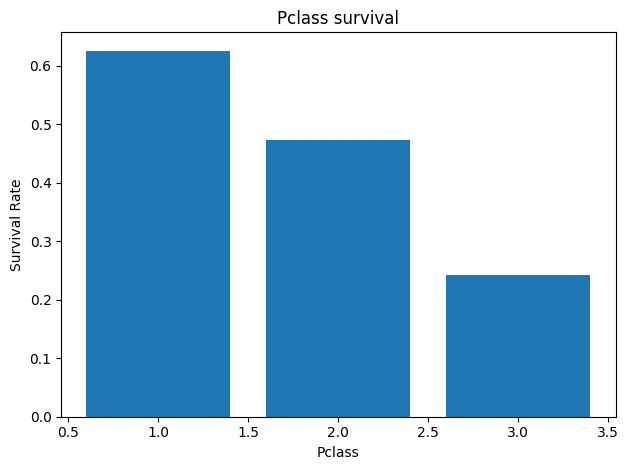

In [ ]:
figu,axe = plt.subplots()
#figu,axe = plt.subplots(figsize=(8,5))
survived_ = df.groupby("Pclass")["Survived"].mean()
axe.bar(x=survived_.index , height= survived_.values)
axe.set_title("Pclass survival")
axe.set_xlabel("Pclass")
axe.set_ylabel("Survival Rate")
plt.tight_layout()
plt.show()